In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device=torch.device("cuda")
elif torch.backends.mps.is_available():
    device=torch.device("mps")
else:
    device=torch.device("cpu")
print(device)

cpu


In [2]:
transform=transforms.Compose([
    transforms.ToTensor()
])

mnist_train=datasets.MNIST(root="./data",train=True,download=True,transform=transform)
mnist_test=datasets.MNIST(root="./data",train=False,download=True,transform=transform)

train_loader=DataLoader(mnist_train,batch_size=128,shuffle=True)
test_loader=DataLoader(mnist_test,batch_size=128,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 47.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.07MB/s]


In [4]:
class VAE(nn.Module):
    def __init__(self,input_dimension=784,hidden_dimension=500,latent_dim=2):
        super().__init__()
        self.encoder_hidden=nn.Linear(input_dimension,hidden_dimension)
        self.mu_layer=nn.Linear(hidden_dimension,latent_dim)
        self.logvar_layer=nn.Linear(hidden_dimension,latent_dim)

        self.decoder_hidden=nn.Linear(latent_dim,hidden_dimension)
        self.decoder_output=nn.Linear(hidden_dimension,input_dimension)

    def encode(self,x):
        h=F.relu(self.encoder_hidden(x))
        mu=self.mu_layer(h)
        logvar=self.logvar_layer(h)
        return mu,logvar

    def reparameterize(self,mu,logvar):
        std=torch.exp(0.5*logvar)
        eps=torch.randn_like(std)
        z=mu+std*eps
        return z

    def decode(self,z):
        h=F.relu(self.decoder_hidden(z))
        reconstruction=torch.sigmoid(self.decoder_output(h))
        return reconstruction

    def forward(self,x):
        mu,logvar=self.encode(x)
        z=self.reparameterize(mu,logvar)
        reconstruction=self.decode(z)
        return reconstruction,mu,logvar

In [5]:
def vae_loss(reconstruction,x,mu,logvar):
    bce=F.binary_cross_entropy(reconstruction,x,reduction="sum")

    mu_squared=mu.pow(2)
    sigma_squared=logvar.exp()
    log_sigma_squared=logvar
    kl_per_dim=mu_squared+sigma_squared-log_sigma_squared-1
    kl=0.5*torch.sum(kl_per_dim)

    return bce+kl

In [8]:
vae_model=VAE(input_dimension=784,hidden_dimension=500,latent_dim=2).to(device)
optimizer=torch.optim.Adam(vae_model.parameters(),lr=1e-3)

epochs=20
train_losses=[]

for epoch in range(epochs):
    vae_model.train()
    epoch_loss=0
    for images,labels in train_loader:
        images=images.view(-1,784).to(device)

        optimizer.zero_grad()
        reconstruction,mu,logvar=vae_model(images)
        loss=vae_loss(reconstruction,images,mu,logvar)
        loss.backward()
        optimizer.step()

        epoch_loss=epoch_loss+loss.item()

    average_loss=epoch_loss/len(mnist_train)
    train_losses.append(average_loss)
    print("Epoch",epoch+1,"loss",average_loss)

Epoch 1 loss 186.83752163085938
Epoch 2 loss 167.18566819661459
Epoch 3 loss 163.28095934244791
Epoch 4 loss 160.76638907877603
Epoch 5 loss 159.04099817708334
Epoch 6 loss 157.77354781901042
Epoch 7 loss 156.66852314453126
Epoch 8 loss 155.76279488932292
Epoch 9 loss 154.88740706380207
Epoch 10 loss 154.2645655436198
Epoch 11 loss 153.61040096028646
Epoch 12 loss 153.13542846679687
Epoch 13 loss 152.6350231282552
Epoch 14 loss 152.21402783203126
Epoch 15 loss 151.80686393229166
Epoch 16 loss 151.42430880533854
Epoch 17 loss 151.04978251953125
Epoch 18 loss 150.74607947591147
Epoch 19 loss 150.46625584309896
Epoch 20 loss 150.19911412760416


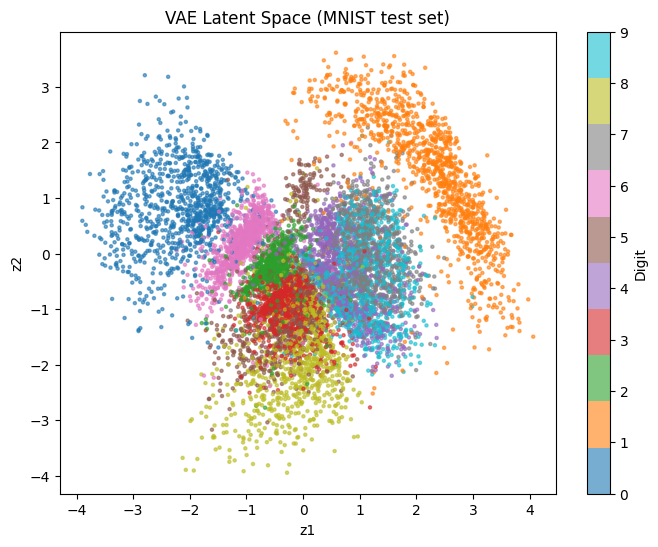

In [10]:
vae_model.eval()
all_mu=[]
all_labels=[]

with torch.no_grad():
    for images,labels in test_loader:
        images=images.view(-1,784).to(device)
        mu,logvar=vae_model.encode(images)
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu=torch.cat(all_mu).numpy()
all_labels=torch.cat(all_labels).numpy()

plt.figure(figsize=(8,6))
scatter=plt.scatter(all_mu[:,0],all_mu[:,1],c=all_labels,cmap="tab10",s=5,alpha=0.6)
plt.colorbar(scatter,label="Digit")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE Latent Space (MNIST test set)")
plt.savefig("vae_latent_space.png",bbox_inches="tight")
plt.show()

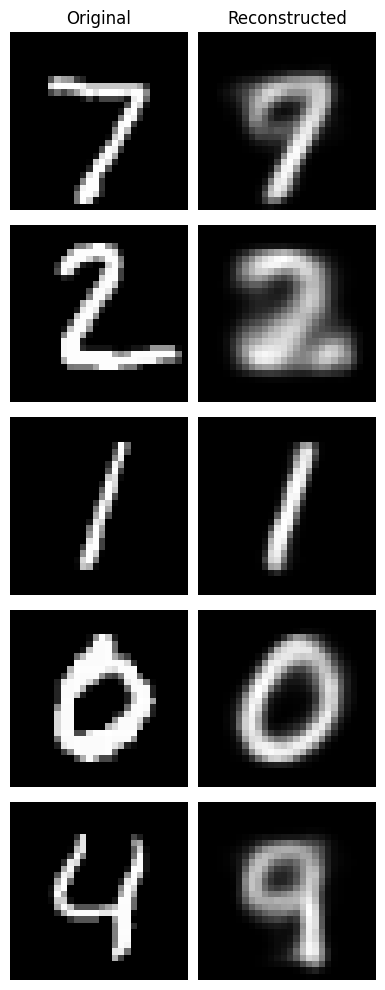

In [9]:
vae_model.eval()
test_images,test_labels=next(iter(test_loader))
test_images_flat=test_images.view(-1,784).to(device)

with torch.no_grad():
    reconstructions,_,_=vae_model(test_images_flat)

n=5
fig,axes=plt.subplots(n,2,figsize=(4,10))
for i in range(n):
    axes[i][0].imshow(test_images[i].squeeze(),cmap="gray")
    axes[i][0].axis("off")
    axes[i][1].imshow(reconstructions[i].cpu().view(28,28),cmap="gray")
    axes[i][1].axis("off")
axes[0][0].set_title("Original")
axes[0][1].set_title("Reconstructed")

plt.tight_layout()
plt.savefig("vae_reconstructions.png",bbox_inches="tight")
plt.show()

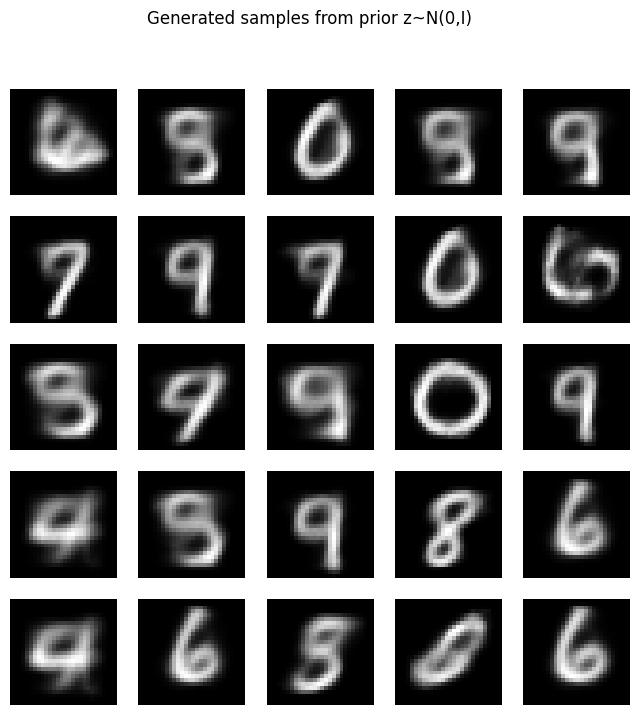

In [11]:
vae_model.eval()
with torch.no_grad():
    z_samples=torch.randn(25,2).to(device)
    generated=vae_model.decode(z_samples)

fig,axes=plt.subplots(5,5,figsize=(8,8))
for i in range(25):
    row=i//5
    col=i%5
    axes[row][col].imshow(generated[i].cpu().view(28,28),cmap="gray")
    axes[row][col].axis("off")
plt.suptitle("Generated samples from prior z~N(0,I)")
plt.savefig("vae_generated.png",bbox_inches="tight")
plt.show()

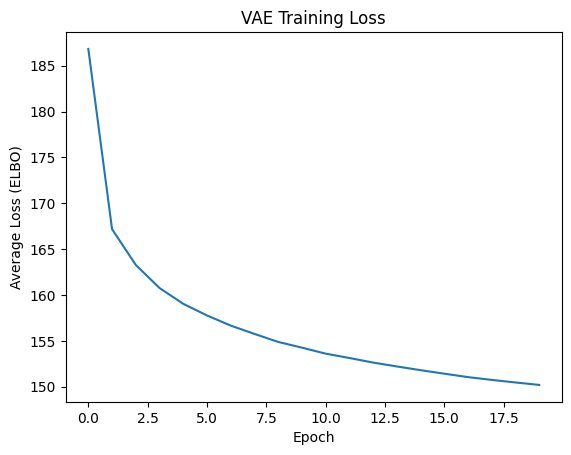

In [12]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss (ELBO)")
plt.title("VAE Training Loss")
plt.savefig("vae_training_loss.png",bbox_inches="tight")
plt.show()

In [15]:
vae_model_d10=VAE(input_dimension=784,hidden_dimension=500,latent_dim=10).to(device)
optimizer_d10=torch.optim.Adam(vae_model_d10.parameters(),lr=1e-3)

d10_losses=[]
for epoch in range(20):
    vae_model_d10.train()
    epoch_loss=0
    for images,labels in train_loader:
        images=images.view(-1,784).to(device)
        optimizer_d10.zero_grad()
        reconstruction,mu,logvar=vae_model_d10(images)
        loss=vae_loss(reconstruction,images,mu,logvar)
        loss.backward()
        optimizer_d10.step()
        epoch_loss=epoch_loss+loss.item()
    average_loss=epoch_loss/len(mnist_train)
    d10_losses.append(average_loss)
    print("Epoch",epoch+1,"loss",average_loss)

Epoch 1 loss 156.85218006184897
Epoch 2 loss 122.94840384114583
Epoch 3 loss 118.20916098632813
Epoch 4 loss 115.75862540690105
Epoch 5 loss 114.17444329427083
Epoch 6 loss 112.99097369791667
Epoch 7 loss 112.10541061197917
Epoch 8 loss 111.33216310221354
Epoch 9 loss 110.68676674804688
Epoch 10 loss 110.12658621419271
Epoch 11 loss 109.61885799153646
Epoch 12 loss 109.19054318033854
Epoch 13 loss 108.81855631510416
Epoch 14 loss 108.36214192708333
Epoch 15 loss 108.06191022135417
Epoch 16 loss 107.74591531575521
Epoch 17 loss 107.45334298502604
Epoch 18 loss 107.17213588867187
Epoch 19 loss 106.92948201497396
Epoch 20 loss 106.72977234700521


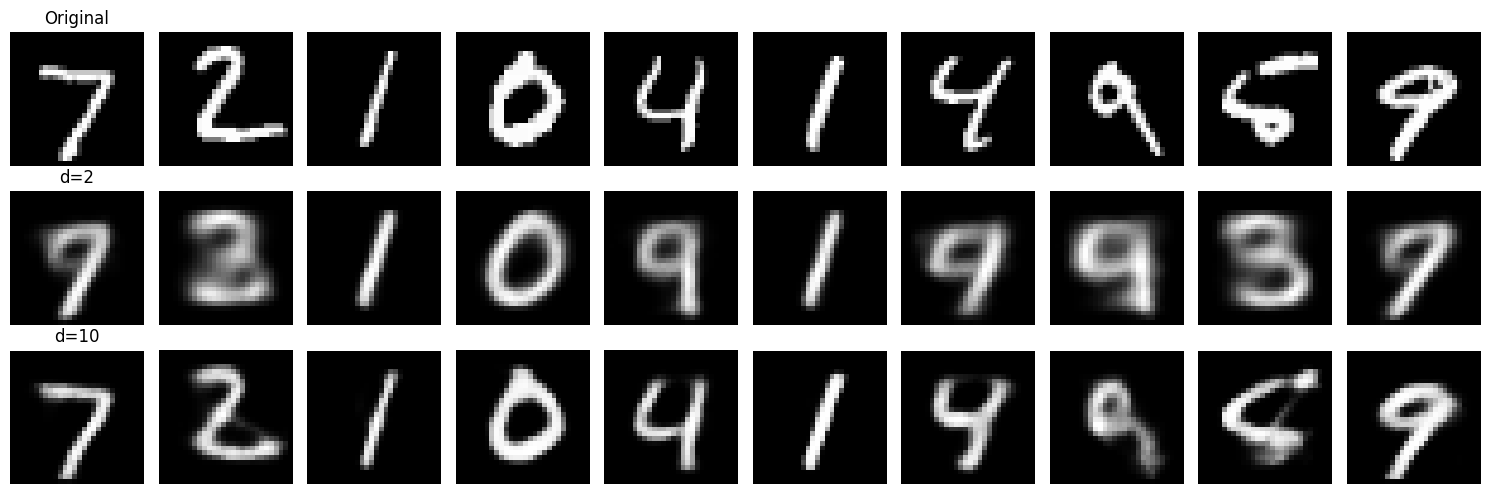

In [16]:
vae_model_d10.eval()
test_images,test_labels=next(iter(test_loader))
test_images_flat=test_images.view(-1,784).to(device)

with torch.no_grad():
    recon_d2,_,_=vae_model(test_images_flat)
    recon_d10,_,_=vae_model_d10(test_images_flat)

n=10
fig,axes=plt.subplots(3,n,figsize=(15,5))
for i in range(n):
    axes[0][i].imshow(test_images[i].squeeze(),cmap="gray")
    axes[0][i].axis("off")
    axes[1][i].imshow(recon_d2[i].cpu().view(28,28),cmap="gray")
    axes[1][i].axis("off")
    axes[2][i].imshow(recon_d10[i].cpu().view(28,28),cmap="gray")
    axes[2][i].axis("off")
axes[0][0].set_title("Original")
axes[1][0].set_title("d=2")
axes[2][0].set_title("d=10")
plt.tight_layout()
plt.savefig("vae_latent_dimension_comparison.png",bbox_inches="tight")
plt.show()

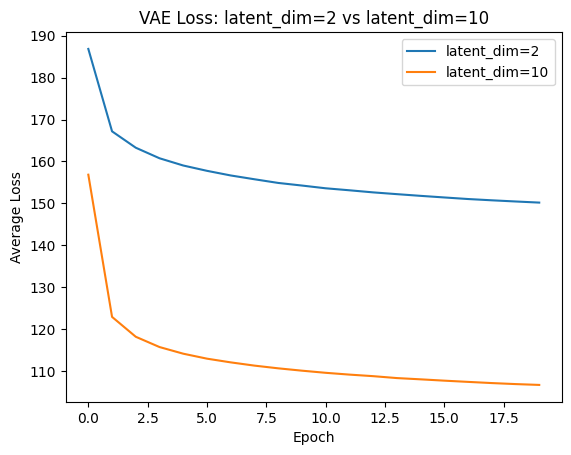

In [17]:
plt.plot(train_losses,label="latent_dim=2")
plt.plot(d10_losses,label="latent_dim=10")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("VAE Loss: latent_dim=2 vs latent_dim=10")
plt.legend()
plt.savefig("vae_loss_comparison.png",bbox_inches="tight")
plt.show()